# DSCI 303 - Project 2

### Sean Graham

**Due: Sunday, May 31, 2020, 11:59 pm**

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

## Part A: Stock Simulation Function

This section involves the creation and testing of a function to generate sequences of simulated daily stock prices, or runs.

In [2]:
def simulate_stock(start,rate,vol,days):
    daily_yields = np.random.normal(loc = rate/252, scale = vol/(252**0.5), size = days)
    cumulative_yields = np.cumsum(daily_yields)
    daily_multipliers = np.exp(cumulative_yields)
    simulated_daily_prices = np.round((start * daily_multipliers),2)
    final_array = np.concatenate([np.array([start]), simulated_daily_prices])
    return final_array

The next cell is used to test the function.

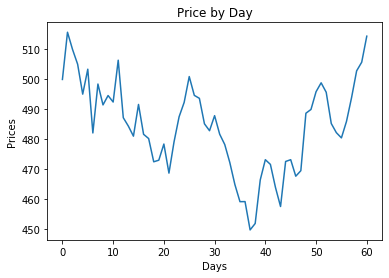

In [3]:
np.random.seed(1)
variable1 = simulate_stock(500,.08,.3,60)

day_range = range(0, len(variable1))
plt.plot(day_range, variable1)

plt.xlabel('Days')
plt.ylabel('Prices')
plt.title('Price by Day')
plt.show()

## Part B: Annual Yield Function

This section involves the creation and testing of a function that takes a simulated run as its input, and calculates the annual yield for that particular run.

In [4]:
def find_yield(run):
    annual_yield = math.log(run[len(run)-1]/run[0]) * (252/(len(run)-1))
    return round(annual_yield, 4)

The next cell is used to test the function.

In [5]:
find_yield(variable1)

0.1196

The next cell will explore the potential variability in the simulated runs by creating and plotting 25 simulated runs.

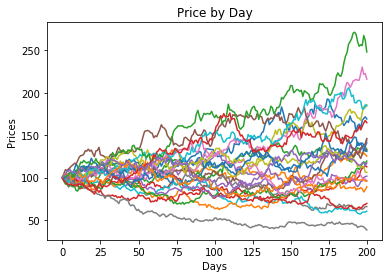

In [6]:
list1 = []
for i in range (0,25):
    variable2 = simulate_stock(100,.06,.4,200)
    day_range = range(0, len(variable2))
    plt.plot(day_range, variable2)
    list1.append(find_yield(variable2))
    
plt.xlabel('Days')
plt.ylabel('Prices')
plt.title('Price by Day')
plt.show()

The next cell displays the yields for the 25 simulated runs.

In [7]:
print(list1)

[0.6611, 0.2836, 0.3501, 0.1506, 0.0198, 0.3635, 0.9697, -0.5283, 0.7798, -0.6351, 0.4319, -0.1446, 0.2234, -0.4586, 0.4608, 0.4768, -0.0479, -1.2092, 0.0748, 0.7724, 0.3386, -0.0558, 1.1441, 0.6283, 0.1978]


## Part C: Finding Seeds that Generate Specific Outcomes

This section involves working with seeds. It involves using trial-and-error to find seeds that result in specific outcomes.

In the cell below, Stock A has the highest simulated final price.

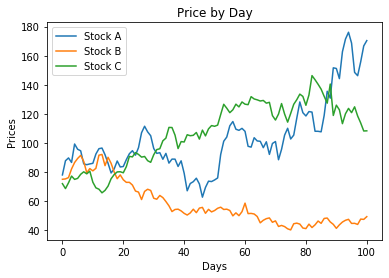

In [8]:
np.random.seed(6789)
Stock_A = simulate_stock(78,.04,1.2,100)
Stock_B = simulate_stock(75,.08,.8,100)
Stock_C = simulate_stock(72,.16,.6,100)

day_range = range(0, len(Stock_A))

plt.plot(day_range, Stock_A, label = 'Stock A')
plt.plot(day_range, Stock_B, label = 'Stock B')
plt.plot(day_range, Stock_C, label = 'Stock C')

plt.legend()
plt.xlabel('Days')
plt.ylabel('Prices')
plt.title('Price by Day')
plt.show()

In the cell below, Stock B has the highest simulated final price.

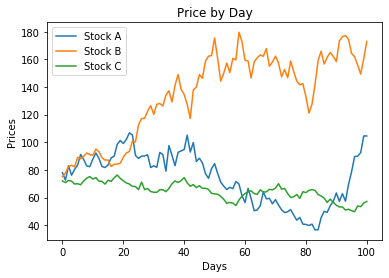

In [9]:
np.random.seed(2345)
Stock_A = simulate_stock(78,.04,1.2,100)
Stock_B = simulate_stock(75,.08,.8,100)
Stock_C = simulate_stock(72,.16,.6,100)

day_range = range(0, len(Stock_A))

plt.plot(day_range, Stock_A, label = 'Stock A')
plt.plot(day_range, Stock_B, label = 'Stock B')
plt.plot(day_range, Stock_C, label = 'Stock C')

plt.legend()
plt.xlabel('Days')
plt.ylabel('Prices')
plt.title('Price by Day')
plt.show()

In the cell below, Stock C has the highest simulated final price.

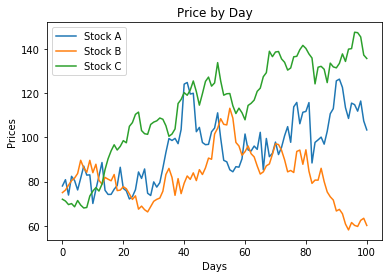

In [10]:
np.random.seed(1234)
Stock_A = simulate_stock(78,.04,1.2,100)
Stock_B = simulate_stock(75,.08,.8,100)
Stock_C = simulate_stock(72,.16,.6,100)

day_range = range(0, len(Stock_A))

plt.plot(day_range, Stock_A, label = 'Stock A')
plt.plot(day_range, Stock_B, label = 'Stock B')
plt.plot(day_range, Stock_C, label = 'Stock C')

plt.legend()
plt.xlabel('Days')
plt.ylabel('Prices')
plt.title('Price by Day')
plt.show()

## Part D: Monte Carlo Simulation

This section involves performing Monte Carlo Simulation (performing several simulations to estimate probabilities relating to the outcome).

In [11]:
def monte_carlo(start,rate,vol,days,num_runs):
    final_prices = []
    annual_yields = []
    for i in range(0, num_runs):
        variable3 = simulate_stock(start,rate,vol,days)
        final_prices.append(variable3[len(variable3)-1])
        variable4 = find_yield(variable3)
        annual_yields.append(variable4)
    return np.array(final_prices), np.array(annual_yields)

This cell tests the function by running a Monte Carlo simulation with a specific seed.

<function matplotlib.pyplot.show(*args, **kw)>

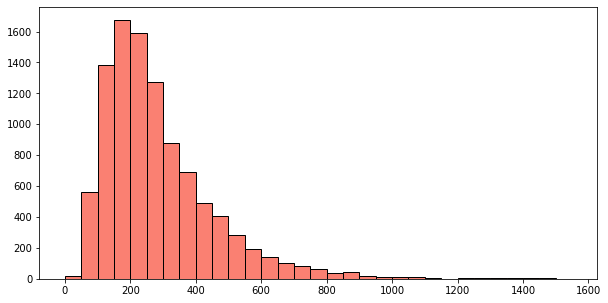

In [12]:
np.random.seed(1)
variable5, variable6 = monte_carlo(200, 0.1, 0.4, 500, 10000)

plt.figure(figsize = [10,5])
plt.hist(variable5, edgecolor='black', color = 'salmon', bins = np.arange(0, 1600, 50))
plt.show

The next cell will display the 10th, 25th, 50th, 75th, and 90th percentiles of the simulated final prices.

In [13]:
tenth = np.percentile(variable5, 10)
twenty_fifth = np.percentile(variable5, 25)
fiftieth = np.percentile(variable5, 50)
seventy_fifth = np.percentile(variable5, 75)
ninetieth = np.percentile(variable5, 90)

print('10th percentile: ' + str(round(tenth, 2)))
print('25th percentile: ' + str(round(twenty_fifth, 2)))
print('50th percentile: ' + str(round(fiftieth, 2)))
print('75th percentile: ' + str(round(seventy_fifth, 2)))
print('90th percentile: ' + str(round(ninetieth, 2)))

10th percentile: 118.05
25th percentile: 165.57
50th percentile: 242.95
75th percentile: 357.56
90th percentile: 505.91


## Part E: Effects of Volatility

This section involves performing two Monte Carlo simulations whose only difference is the volitility.

In [14]:
np.random.seed(1)
A_prices, A_yield = monte_carlo(100,.12,.3,150,10000)
B_prices, B_yield = monte_carlo(100,.12,.7,150,10000)

print('Average Annual Yield for A over 10000 runs: ' + str(round(np.mean(A_yield), 4)))
print('Average Annual Yield for B over 10000 runs: ' + str(round(np.mean(B_yield), 4)))

Average Annual Yield for A over 10000 runs: 0.1218
Average Annual Yield for B over 10000 runs: 0.1128


The next cell will visually inspect the results of the two previous simulations by plotting histograms of the final prices.

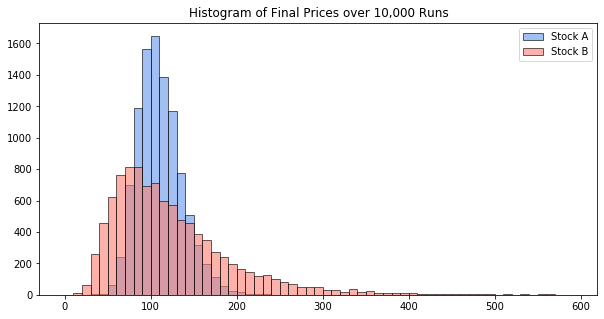

In [15]:
plt.figure(figsize = [10,5])

plt.hist(A_prices, edgecolor = 'black', color = 'cornflowerblue', alpha = 0.6, bins = np.arange(0,600, 10), label = 'Stock A')
plt.hist(B_prices, edgecolor = 'black', color = 'salmon', alpha = 0.6, bins = np.arange(0,600, 10), label = 'Stock B')

plt.legend()
plt.title('Histogram of Final Prices over 10,000 Runs')
plt.show()

## Part F: Comparing Two Stocks

This section involves using Monte Carlo simulation to estimate probabilities relating to the performance of two stocks with different parameters.

In [16]:
np.random.seed(1)
A_prices, A_yield = monte_carlo(120,.08,.2,252,10000)
B_prices, B_yield = monte_carlo(120,.05,.5,252,10000)

proportion_1 = np.sum(A_prices > B_prices) / len(A_prices)
proportion_2 = np.sum(A_prices > 150) / len(A_prices)
proportion_3 = np.sum(B_prices > 150) / len(B_prices)
proportion_4 = np.sum(A_prices < 100) / len(A_prices)
proportion_5 = np.sum(B_prices < 100) / len(B_prices)

print('Proportions of runs in which...')
print('------------------------------- ')
print('A ends above B: ' + str(round(proportion_1, 4)))
print()
print('A ends above 150: ' + str(round(proportion_2, 4)))
print('B ends above 150: ' + str(round(proportion_3, 4)))
print()
print('A ends below 100: ' + str(round(proportion_4, 4)))
print('B ends below 100: ' + str(round(proportion_5, 4)))

Proportions of runs in which...
------------------------------- 
A ends above B: 0.5206

A ends above 150: 0.2338
B ends above 150: 0.3619

A ends below 100: 0.095
B ends below 100: 0.3195


## Part G: Expected Call Payoff

This section will involve using Monte Carlo to estimate the expected payoff of a call on a particular stock. This will be based off the expiration date, the strike price (K), and the price of the stock when the call expires (S).

In [22]:
S, Yield = monte_carlo(200,.11,.4,150,10000)
K = 225
Payoff = np.where((S-K) > 0, (S-K), 0)
average_call_payoff = np.mean(Payoff)
print(average_call_payoff)

27.514083999999997
